In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load Results

In [2]:
summary = pd.read_csv("results/bench_summary.csv")
per_file = pd.read_csv("results/combined_per_file.csv")

summary

,model,n_files,median_latency_ms,mean_latency_ms,p95_latency_ms,std_latency_ms,mean_wer,corpus_wer
0,facebook_wav2vec2-base-960h,41,697.1196,598.342939,870.79326,230.679225,0.209330,0.205323
1,voskadapter,41,2030.5851,2051.226478,2935.82333,541.438511,0.190708,0.197719
2,whisper_greedy,41,5919.6758,6973.999790,6677.76647,13090.210559,0.047522,0.053232
3,whisperadapter,41,2871.6482,3156.808885,5840.29887,849.099347,0.047522,0.053232


In [3]:
# Keep only the 3 benchmarked models
valid_models = [
    "whisperadapter",
    "facebook_wav2vec2-base-960h",
    "voskadapter",
]

summary = summary[summary["model"].isin(valid_models)].copy()
per_file = per_file[per_file["model"].isin(valid_models)].copy()

summary

,model,n_files,median_latency_ms,mean_latency_ms,p95_latency_ms,std_latency_ms,mean_wer,corpus_wer
0,facebook_wav2vec2-base-960h,41,697.1196,598.342939,870.79326,230.679225,0.209330,0.205323
1,voskadapter,41,2030.5851,2051.226478,2935.82333,541.438511,0.190708,0.197719
3,whisperadapter,41,2871.6482,3156.808885,5840.29887,849.099347,0.047522,0.053232


In [4]:
# Optional: rename for prettier charts
name_map = {
    "whisperadapter": "Whisper",
    "facebook_wav2vec2-base-960h": "Wav2Vec2",
    "voskadapter": "Vosk",
}

summary["model_pretty"] = summary["model"].map(name_map)
per_file["model_pretty"] = per_file["model"].map(name_map)

summary

,model,n_files,median_latency_ms,mean_latency_ms,p95_latency_ms,std_latency_ms,mean_wer,corpus_wer,model_pretty
0,facebook_wav2vec2-base-960h,41,697.1196,598.342939,870.79326,230.679225,0.209330,0.205323,Wav2Vec2
1,voskadapter,41,2030.5851,2051.226478,2935.82333,541.438511,0.190708,0.197719,Vosk
3,whisperadapter,41,2871.6482,3156.808885,5840.29887,849.099347,0.047522,0.053232,Whisper


In [5]:
# Check that references and WER are present
per_file[["file", "model_pretty", "canonical_transcript", "reference", "wer"]].head(10)

,file,model_pretty,canonical_transcript,reference,wer
0,atm_limit_01.wav,Wav2Vec2,HOW MUCH MONEY CAN I THIK OUT ATHIATHIA,how much money can I take out at the ATM,0.400000
1,atm_limit_02.wav,Wav2Vec2,HOW MUCH MONEY CAN I WITHDRAW AT THE A T M,how much money can I withdraw at the ATM,0.333333
2,atm_limit_03.wav,Wav2Vec2,WHAT IS MY LIMIT AT THE EIGTM,what is my limit at the ATM,0.142857
3,balance_01.wav,Wav2Vec2,GIM MA THING MIGHT COUNT BALLA,can you see my account balance,1.000000
4,balance_02.wav,Wav2Vec2,WHAT IS MY ACCOUNT BALANCE,what is my account balance,0.000000
5,balance_03.wav,Wav2Vec2,SHOW ME MY ACCOUNT BALANCE,show me my account balance,0.000000
6,balance_04.wav,Wav2Vec2,I WOULD LIKE TO KNOW WHAT MY CURRENT ACCOUNT B...,I would like to know what my current account b...,0.000000
7,balance_05.wav,Wav2Vec2,WHAT'S MY CURRENT BALANTH,what's my current balance,0.250000
8,balance_06.wav,Wav2Vec2,ACCOUNT BALANCE,account balance,0.000000
9,balance_07.wav,Wav2Vec2,SHOW ME MY ACCOUNT BALANCE PLEASE,show me my account balance please,0.000000


In [6]:
# Clean summary table for presentation
summary_view = summary[
    [
        "model_pretty",
        "n_files",
        "median_latency_ms",
        "mean_latency_ms",
        "p95_latency_ms",
        "mean_wer",
        "corpus_wer",
    ]
].copy()

summary_view = summary_view.sort_values("median_latency_ms")
summary_view

,model_pretty,n_files,median_latency_ms,mean_latency_ms,p95_latency_ms,mean_wer,corpus_wer
0,Wav2Vec2,41,697.1196,598.342939,870.79326,0.209330,0.205323
1,Vosk,41,2030.5851,2051.226478,2935.82333,0.190708,0.197719
3,Whisper,41,2871.6482,3156.808885,5840.29887,0.047522,0.053232


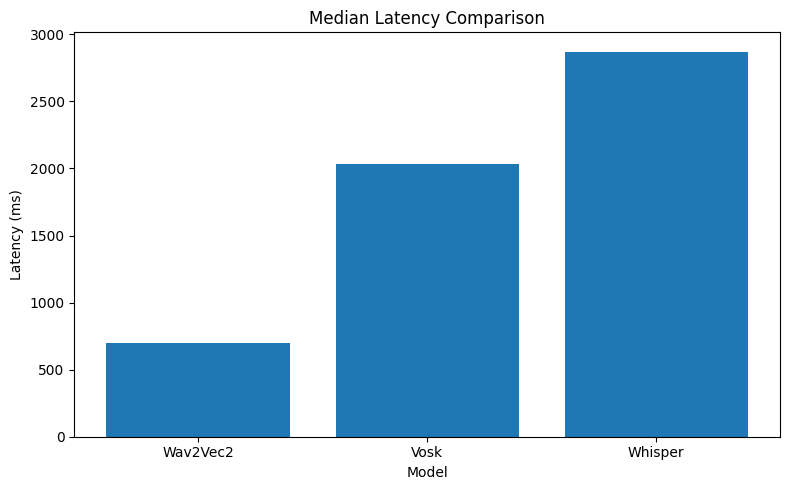

In [7]:
# Latency comparison
plt.figure(figsize=(8, 5))
plt.bar(summary_view["model_pretty"], summary_view["median_latency_ms"])
plt.title("Median Latency Comparison")
plt.xlabel("Model")
plt.ylabel("Latency (ms)")
plt.tight_layout()
plt.show()

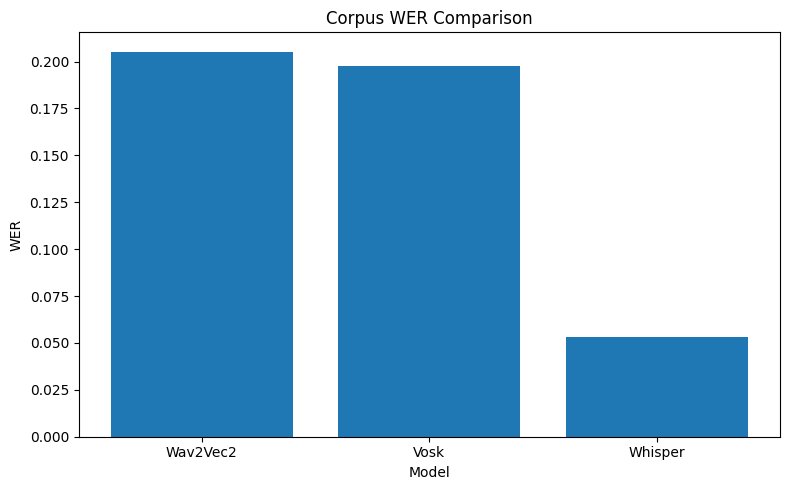

In [8]:
# WER comparison
plt.figure(figsize=(8, 5))
plt.bar(summary_view["model_pretty"], summary_view["corpus_wer"])
plt.title("Corpus WER Comparison")
plt.xlabel("Model")
plt.ylabel("WER")
plt.tight_layout()
plt.show()

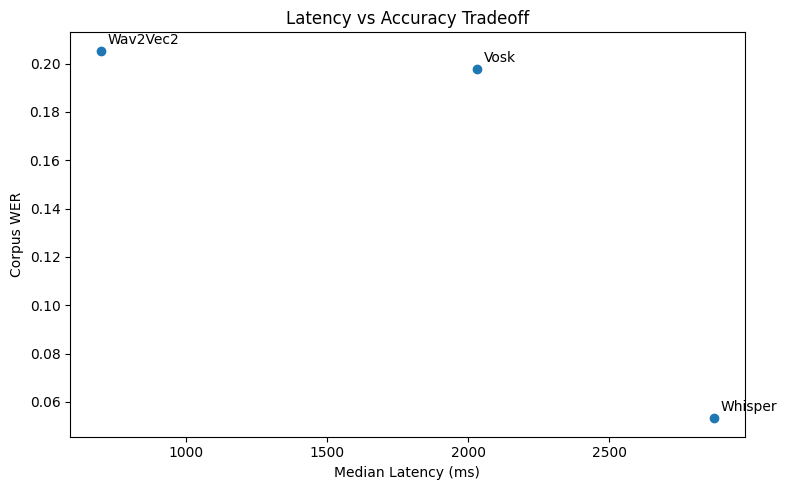

In [9]:
# Latency vs accuracy tradeoff
plt.figure(figsize=(8, 5))
plt.scatter(summary_view["median_latency_ms"], summary_view["corpus_wer"])

for _, row in summary_view.iterrows():
    plt.annotate(
        row["model_pretty"],
        (row["median_latency_ms"], row["corpus_wer"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Latency vs Accuracy Tradeoff")
plt.xlabel("Median Latency (ms)")
plt.ylabel("Corpus WER")
plt.tight_layout()
plt.show()

In [10]:
# Show a few transcript examples for each model
per_file[
    ["model_pretty", "file", "reference", "canonical_transcript", "wer"]
].sort_values(["model_pretty", "file"]).head(15)

,model_pretty,file,reference,canonical_transcript,wer
41,Vosk,atm_limit_01.wav,how much money can I take out at the ATM,how much money can i say l at eight pm,0.400000
42,Vosk,atm_limit_02.wav,how much money can I withdraw at the ATM,how much money to withdraw the a m,0.555556
43,Vosk,atm_limit_03.wav,what is my limit at the ATM,what is my limit at the hm,0.142857
44,Vosk,balance_01.wav,can you see my account balance,in my count bella,0.833333
45,Vosk,balance_02.wav,what is my account balance,what is my account balance,0.000000
46,Vosk,balance_03.wav,show me my account balance,show me my account balance,0.000000
47,Vosk,balance_04.wav,I would like to know what my current account b...,i would like to know what my current account b...,0.000000
48,Vosk,balance_05.wav,what's my current balance,what's my current balance,0.000000
49,Vosk,balance_06.wav,account balance,account balance,0.000000
50,Vosk,balance_07.wav,show me my account balance please,show me my account balance please,0.000000


In [11]:
# Save a clean table for your slides if needed
summary_view.to_csv("results/summary_for_slides.csv", index=False)
summary_view

,model_pretty,n_files,median_latency_ms,mean_latency_ms,p95_latency_ms,mean_wer,corpus_wer
0,Wav2Vec2,41,697.1196,598.342939,870.79326,0.209330,0.205323
1,Vosk,41,2030.5851,2051.226478,2935.82333,0.190708,0.197719
3,Whisper,41,2871.6482,3156.808885,5840.29887,0.047522,0.053232


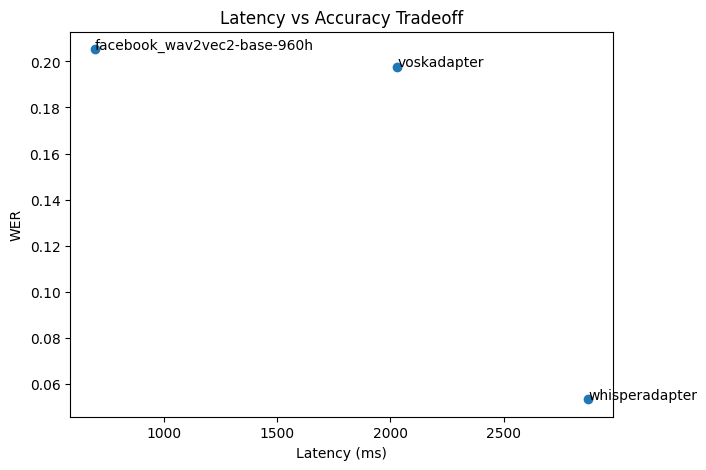

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(summary['median_latency_ms'], summary['corpus_wer'])

for i, row in summary.iterrows():
    plt.text(row['median_latency_ms'], row['corpus_wer'], row['model'])

plt.xlabel("Latency (ms)")
plt.ylabel("WER")
plt.title("Latency vs Accuracy Tradeoff")
plt.show()

Show Table

In [13]:
# Show a few transcript examples for each model
per_file[
    ["model_pretty", "file", "reference", "canonical_transcript", "wer"]
].sort_values(["model_pretty", "file"]).head(15)

,model_pretty,file,reference,canonical_transcript,wer
41,Vosk,atm_limit_01.wav,how much money can I take out at the ATM,how much money can i say l at eight pm,0.400000
42,Vosk,atm_limit_02.wav,how much money can I withdraw at the ATM,how much money to withdraw the a m,0.555556
43,Vosk,atm_limit_03.wav,what is my limit at the ATM,what is my limit at the hm,0.142857
44,Vosk,balance_01.wav,can you see my account balance,in my count bella,0.833333
45,Vosk,balance_02.wav,what is my account balance,what is my account balance,0.000000
46,Vosk,balance_03.wav,show me my account balance,show me my account balance,0.000000
47,Vosk,balance_04.wav,I would like to know what my current account b...,i would like to know what my current account b...,0.000000
48,Vosk,balance_05.wav,what's my current balance,what's my current balance,0.000000
49,Vosk,balance_06.wav,account balance,account balance,0.000000
50,Vosk,balance_07.wav,show me my account balance please,show me my account balance please,0.000000


In [14]:
# Save a clean table for your slides if needed
summary_view.to_csv("results/summary_for_slides.csv", index=False)
summary_view

,model_pretty,n_files,median_latency_ms,mean_latency_ms,p95_latency_ms,mean_wer,corpus_wer
0,Wav2Vec2,41,697.1196,598.342939,870.79326,0.209330,0.205323
1,Vosk,41,2030.5851,2051.226478,2935.82333,0.190708,0.197719
3,Whisper,41,2871.6482,3156.808885,5840.29887,0.047522,0.053232


# Whisper Inference Optimization Analysis

This section compares the baseline Whisper model with inference-time optimizations:

- Greedy decoding
- No previous-text conditioning
- Silence trimming using VAD

In [3]:
## Imports and file definitions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results")

experiment_files = {
    "Baseline Whisper": RESULTS_DIR / "whisperadapter_per_file.csv",
    "Greedy Whisper": RESULTS_DIR / "whisper_greedy_per_file.csv",
    "No-context Whisper": RESULTS_DIR / "whisper_no_context_per_file.csv",
    "Whisper + VAD": RESULTS_DIR / "whisper_vad_per_file.csv",
}

In [4]:
## Load available results

experiment_results = {}

for experiment, file_path in experiment_files.items():
    if file_path.exists():
        df = pd.read_csv(file_path)
        df["experiment"] = experiment
        experiment_results[experiment] = df

        print(f"Loaded: {experiment} — {len(df)} files")
    else:
        print(f"Not available yet: {file_path}")

Loaded: Baseline Whisper — 41 files
Loaded: Greedy Whisper — 41 files
Loaded: No-context Whisper — 41 files
Loaded: Whisper + VAD — 41 files


In [5]:
## Combine results

if not experiment_results:
    raise FileNotFoundError(
        "No Whisper experiment result files were found."
    )

optimization_per_file = pd.concat(
    experiment_results.values(),
    ignore_index=True
)

optimization_per_file[
    ["experiment", "file", "mean_latency_ms", "median_latency_ms", "wer"]
].head()

,experiment,file,mean_latency_ms,median_latency_ms,wer
0,Baseline Whisper,atm_limit_01.wav,3285.311967,3351.3399,0.0
1,Baseline Whisper,atm_limit_02.wav,3268.207733,3237.4368,0.0
2,Baseline Whisper,atm_limit_03.wav,3144.788867,3155.8753,0.0
3,Baseline Whisper,balance_01.wav,2956.777367,2955.0009,0.5
4,Baseline Whisper,balance_02.wav,2769.291333,2761.6701,0.0


In [6]:
## Validate files

file_counts = (
    optimization_per_file
    .groupby("experiment")["file"]
    .nunique()
    .reset_index(name="number_of_files")
)

file_counts

,experiment,number_of_files
0,Baseline Whisper,41
1,Greedy Whisper,41
2,No-context Whisper,41
3,Whisper + VAD,41


In [7]:
## Create optimization summary

optimization_summary = (
    optimization_per_file
    .groupby("experiment")
    .agg(
        n_files=("file", "nunique"),
        mean_latency_ms=("mean_latency_ms", "mean"),
        median_latency_ms=("median_latency_ms", "median"),
        p95_latency_ms=(
            "mean_latency_ms",
            lambda values: np.percentile(values.dropna(), 95)
        ),
        maximum_latency_ms=("mean_latency_ms", "max"),
        mean_wer=("wer", "mean"),
    )
    .reset_index()
)

optimization_summary

,experiment,n_files,mean_latency_ms,median_latency_ms,p95_latency_ms,maximum_latency_ms,mean_wer
0,Baseline Whisper,41,3156.808885,2871.6482,5758.869467,6232.081333,0.047522
1,Greedy Whisper,41,6973.999790,5919.6758,6497.519833,88103.877767,0.047522
2,No-context Whisper,41,6667.441502,3384.2372,12697.801100,15077.635833,0.047522
3,Whisper + VAD,41,21922.707660,7182.1817,35601.517033,206057.072333,0.057820


In [8]:
## Compare against baseline

baseline_rows = optimization_summary[
    optimization_summary["experiment"] == "Baseline Whisper"
]

if baseline_rows.empty:
    raise ValueError("Baseline Whisper results are required.")

baseline_mean_latency = baseline_rows["mean_latency_ms"].iloc[0]
baseline_median_latency = baseline_rows["median_latency_ms"].iloc[0]
baseline_mean_wer = baseline_rows["mean_wer"].iloc[0]

optimization_summary["mean_latency_improvement_pct"] = (
    (
        baseline_mean_latency
        - optimization_summary["mean_latency_ms"]
    )
    / baseline_mean_latency
) * 100

optimization_summary["median_latency_improvement_pct"] = (
    (
        baseline_median_latency
        - optimization_summary["median_latency_ms"]
    )
    / baseline_median_latency
) * 100

optimization_summary["wer_change"] = (
    optimization_summary["mean_wer"]
    - baseline_mean_wer
)

optimization_summary = optimization_summary.sort_values(
    "median_latency_ms"
)

optimization_summary

,experiment,n_files,mean_latency_ms,median_latency_ms,p95_latency_ms,maximum_latency_ms,mean_wer,mean_latency_improvement_pct,median_latency_improvement_pct,wer_change
0,Baseline Whisper,41,3156.808885,2871.6482,5758.869467,6232.081333,0.047522,0.000000,0.000000,0.000000
2,No-context Whisper,41,6667.441502,3384.2372,12697.801100,15077.635833,0.047522,-111.208272,-17.849993,0.000000
1,Greedy Whisper,41,6973.999790,5919.6758,6497.519833,88103.877767,0.047522,-120.919291,-106.142096,0.000000
3,Whisper + VAD,41,21922.707660,7182.1817,35601.517033,206057.072333,0.057820,-594.457867,-150.106601,0.010298


Interpretation:

Positive latency improvement means faster than baseline.
Negative latency improvement means slower than baseline.
A WER change of 0 means accuracy remained unchanged.

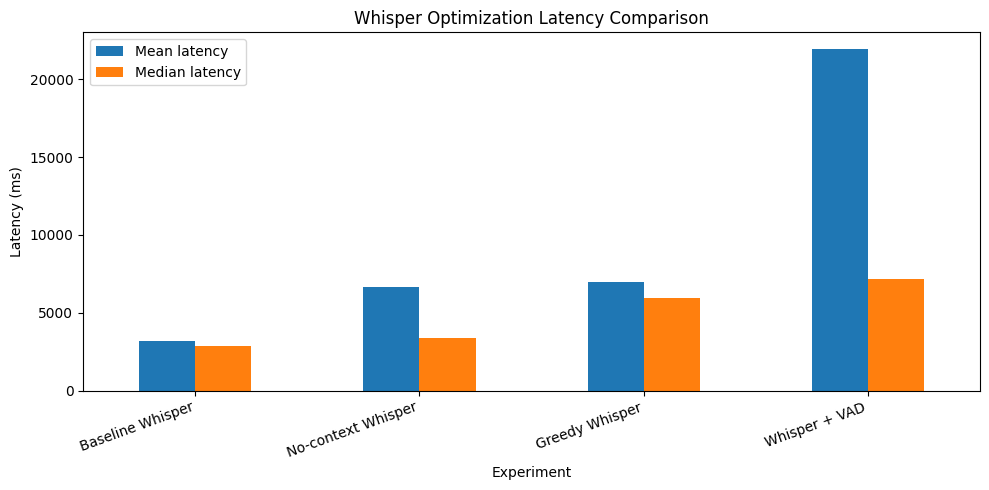

In [9]:
## Mean and median latency graph

latency_chart = (
    optimization_summary
    .set_index("experiment")[
        ["mean_latency_ms", "median_latency_ms"]
    ]
)

latency_chart.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Whisper Optimization Latency Comparison")
plt.xlabel("Experiment")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=20, ha="right")
plt.legend(["Mean latency", "Median latency"])
plt.tight_layout()
plt.show()

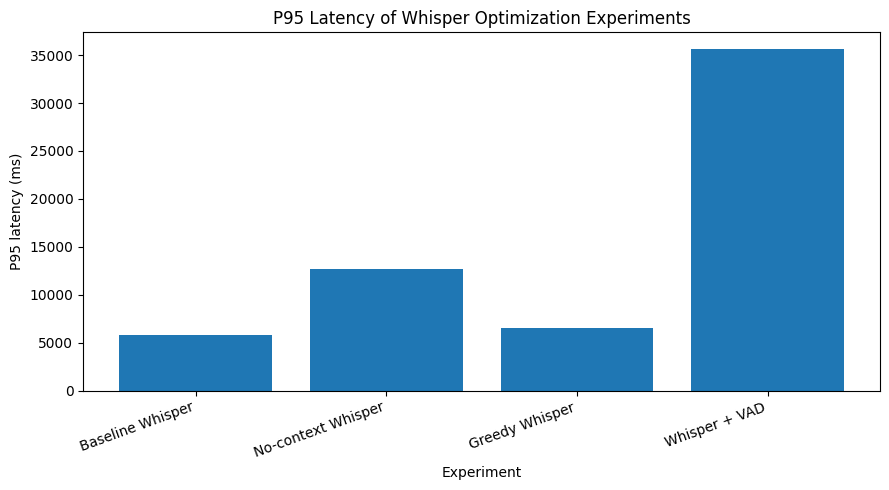

In [10]:
## P95 latency graph

plt.figure(figsize=(9, 5))

plt.bar(
    optimization_summary["experiment"],
    optimization_summary["p95_latency_ms"]
)

plt.title("P95 Latency of Whisper Optimization Experiments")
plt.xlabel("Experiment")
plt.ylabel("P95 latency (ms)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

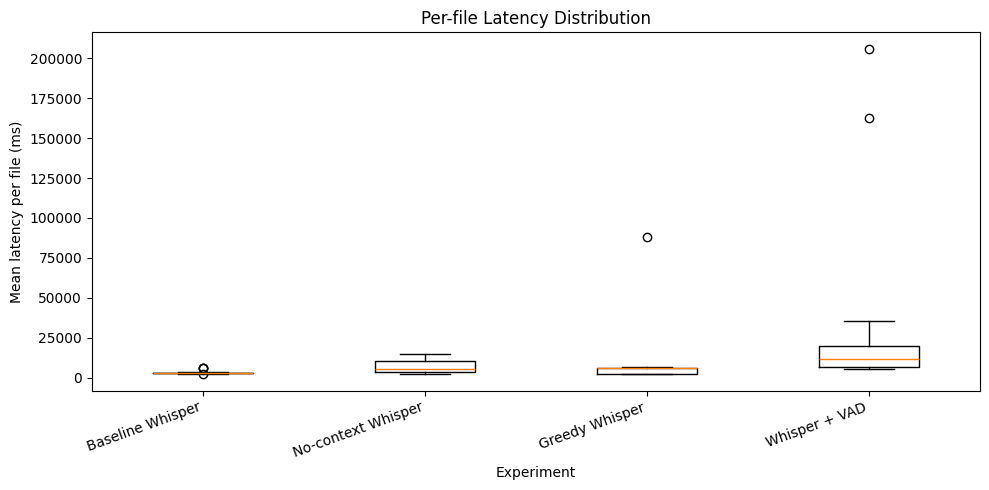

In [11]:
## Latency distribution

experiment_order = optimization_summary["experiment"].tolist()

latency_distributions = [
    optimization_per_file.loc[
        optimization_per_file["experiment"] == experiment,
        "mean_latency_ms"
    ].dropna()
    for experiment in experiment_order
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    latency_distributions,
    tick_labels=experiment_order,
    showfliers=True
)

plt.title("Per-file Latency Distribution")
plt.xlabel("Experiment")
plt.ylabel("Mean latency per file (ms)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

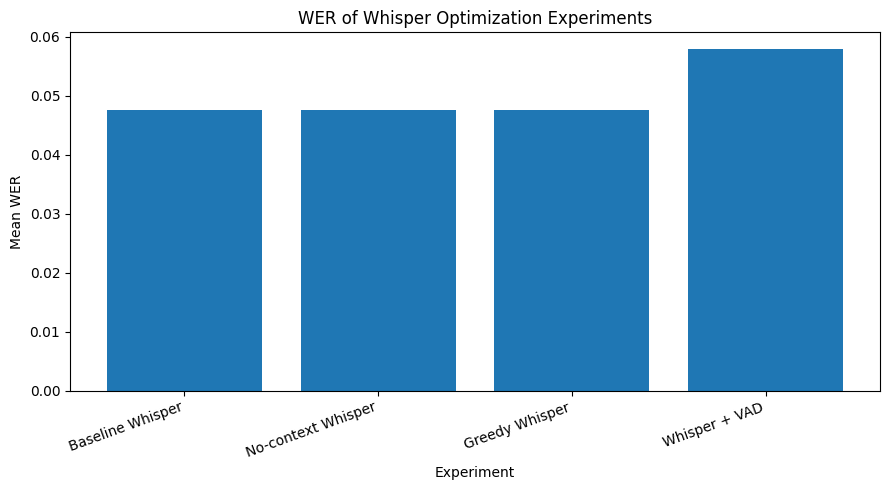

In [13]:
## WER comparisonLatency Bar Chart

plt.figure(figsize=(9, 5))

plt.bar(
    optimization_summary["experiment"],
    optimization_summary["mean_wer"]
)

plt.title("WER of Whisper Optimization Experiments")
plt.xlabel("Experiment")
plt.ylabel("Mean WER")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

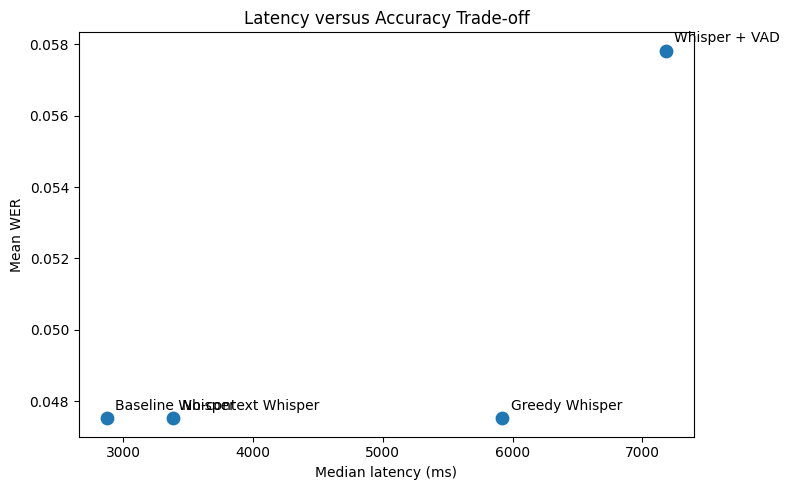

In [14]:
## Latency versus accuracy

plt.figure(figsize=(8, 5))

plt.scatter(
    optimization_summary["median_latency_ms"],
    optimization_summary["mean_wer"],
    s=80
)

for _, row in optimization_summary.iterrows():
    plt.annotate(
        row["experiment"],
        (
            row["median_latency_ms"],
            row["mean_wer"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.title("Latency versus Accuracy Trade-off")
plt.xlabel("Median latency (ms)")
plt.ylabel("Mean WER")
plt.tight_layout()
plt.show()

In [15]:
## Identify latency outliers

slowest_files = (
    optimization_per_file
    .sort_values(
        ["experiment", "mean_latency_ms"],
        ascending=[True, False]
    )
    .groupby("experiment")
    .head(10)
)

slowest_files[
    [
        "experiment",
        "file",
        "mean_latency_ms",
        "median_latency_ms",
        "wer",
    ]
]

,experiment,file,mean_latency_ms,median_latency_ms,wer
39,Baseline Whisper,pay_bill_09.wav,6232.081333,6196.7340,0.000000
40,Baseline Whisper,pay_bill_10.wav,6003.587800,5864.0997,0.000000
35,Baseline Whisper,pay_bill_05.wav,5758.869467,5787.6153,0.000000
34,Baseline Whisper,pay_bill_04.wav,3521.135933,2932.1664,0.000000
38,Baseline Whisper,pay_bill_08.wav,3435.229867,2459.0668,0.000000
11,Baseline Whisper,balance_09.wav,3294.666433,3357.0871,0.142857
0,Baseline Whisper,atm_limit_01.wav,3285.311967,3351.3399,0.000000
1,Baseline Whisper,atm_limit_02.wav,3268.207733,3237.4368,0.000000
12,Baseline Whisper,balance_10.wav,3157.199200,3173.4727,0.166667
2,Baseline Whisper,atm_limit_03.wav,3144.788867,3155.8753,0.000000


In [16]:
## Baseline versus greedy comparison

if (
    "Baseline Whisper" in experiment_results
    and "Greedy Whisper" in experiment_results
):
    baseline = experiment_results["Baseline Whisper"]
    greedy = experiment_results["Greedy Whisper"]

    greedy_comparison = baseline[
        ["file", "mean_latency_ms", "median_latency_ms", "wer"]
    ].merge(
        greedy[
            ["file", "mean_latency_ms", "median_latency_ms", "wer"]
        ],
        on="file",
        suffixes=("_baseline", "_greedy")
    )

    greedy_comparison["latency_difference_ms"] = (
        greedy_comparison["mean_latency_ms_greedy"]
        - greedy_comparison["mean_latency_ms_baseline"]
    )

    greedy_comparison["latency_change_pct"] = (
        greedy_comparison["latency_difference_ms"]
        / greedy_comparison["mean_latency_ms_baseline"]
    ) * 100

    display(
        greedy_comparison.sort_values(
            "latency_difference_ms",
            ascending=False
        ).head(15)
    )

,file,mean_latency_ms_baseline,median_latency_ms_baseline,wer_baseline,mean_latency_ms_greedy,median_latency_ms_greedy,wer_greedy,latency_difference_ms,latency_change_pct
19,cash_deposit_02.wav,2395.098500,2401.4220,0.222222,88103.877767,83353.7274,0.222222,85708.779267,3578.507492
6,balance_04.wav,3026.880533,3007.1380,0.000000,6497.519833,6494.5976,0.000000,3470.639300,114.660597
22,cash_deposit_05.wav,3117.976567,3095.5045,0.000000,6530.924700,6484.3778,0.000000,3412.948133,109.460352
24,cash_deposit_07.wav,2797.812200,2808.6953,0.000000,6102.888833,6088.0879,0.000000,3305.076633,118.130753
23,cash_deposit_06.wav,2856.926933,2834.1904,0.000000,6158.230300,6151.5274,0.000000,3301.303367,115.554351
21,cash_deposit_04.wav,2861.058200,2851.5877,0.000000,6138.653567,6200.5257,0.000000,3277.595367,114.558850
20,cash_deposit_03.wav,2966.045733,2929.2324,0.000000,6225.701533,5919.6758,0.000000,3259.655800,109.899040
4,balance_02.wav,2769.291333,2761.6701,0.000000,5997.226267,6018.0716,0.000000,3227.934933,116.561768
10,balance_08.wav,2804.355267,2819.4347,0.000000,6031.725667,6016.3765,0.000000,3227.370400,115.084221
1,atm_limit_02.wav,3268.207733,3237.4368,0.000000,6492.963900,6481.6672,0.000000,3224.756167,98.670477


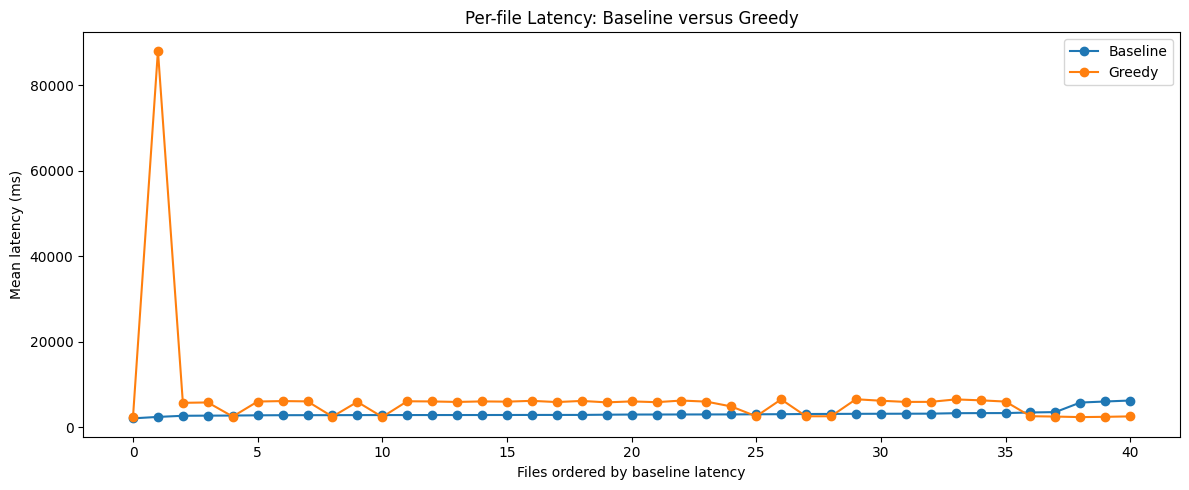

In [17]:
## Per-file baseline versus greedy graph

if "greedy_comparison" in globals():
    greedy_plot = greedy_comparison.sort_values(
        "mean_latency_ms_baseline"
    ).reset_index(drop=True)

    plt.figure(figsize=(12, 5))

    plt.plot(
        greedy_plot.index,
        greedy_plot["mean_latency_ms_baseline"],
        marker="o",
        label="Baseline"
    )

    plt.plot(
        greedy_plot.index,
        greedy_plot["mean_latency_ms_greedy"],
        marker="o",
        label="Greedy"
    )

    plt.title("Per-file Latency: Baseline versus Greedy")
    plt.xlabel("Files ordered by baseline latency")
    plt.ylabel("Mean latency (ms)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
## Save summary

optimization_summary.to_csv(
    RESULTS_DIR / "whisper_optimization_summary.csv",
    index=False
)

optimization_summary

,experiment,n_files,mean_latency_ms,median_latency_ms,p95_latency_ms,maximum_latency_ms,mean_wer,mean_latency_improvement_pct,median_latency_improvement_pct,wer_change
0,Baseline Whisper,41,3156.808885,2871.6482,5758.869467,6232.081333,0.047522,0.000000,0.000000,0.000000
2,No-context Whisper,41,6667.441502,3384.2372,12697.801100,15077.635833,0.047522,-111.208272,-17.849993,0.000000
1,Greedy Whisper,41,6973.999790,5919.6758,6497.519833,88103.877767,0.047522,-120.919291,-106.142096,0.000000
3,Whisper + VAD,41,21922.707660,7182.1817,35601.517033,206057.072333,0.057820,-594.457867,-150.106601,0.010298
